| Technological Institute of the Philippines | Quezon City - Computer Engineering |
|-------------------------------------------|------------------------------------|
| **Course Code:** | CPE 027 |
| **Code Title:** | Digital Signal Processing and Applications |
| **1st Semester** | AY 2026-2027 |
| **ACTIVITY NO. 3** | **Statistical Analysis of Signals** |
| **Name:** | Pascual, Ken Leonard |
| **Section:** | CPE41S2 |
| **Date Performed:** | 24 July 2026 |
| **Date Submitted:** | 24 July 2026 |
| **Instructor:** | Engr. Jimlord M. Quejado |


## 1. Objectives

This activity aims to introduce the concept of statistical analysis for large-volume signals, such as the mean, standard deviation, noise, and error. This includes programmatically visualizing, calculating, and storing, using a high-level language

## 2. Intended Learning Outcomes (ILOs)
After completion of this activity, the students should be able to:

1. Develop a program that calculates and visualizes the statistical properties of a given signal dataset.

## 3. Discussion


## 4. Resources
The activity will require the following software, tools and equipment:
* IDE or any online code editor
* Google Drive for csv files: https://drive.google.com/drive/folders/1rBRuSPATvIe8h6--bhXZvys1en3AEE_G


## 5. Directions:

A sensor managed to sample data in 0 to 195 steps. You will be given access to a repository of each sample in the form of CSV files. Use only csv files coming from **machine B1**. There is a total of 196 sample files, each of those files contain 41,666 data points. Disregard the file labeled: Base Noise.

1. Create a program that can calculate the mean, standard deviation, and standard error of voltage and resistance for each STEP, consolidate it in a separate (new) CSV file.

In [2]:
# Import required libraries: pandas for data handling, numpy for math,
# os/glob for file paths, scipy for statistical functions
import pandas as pd
import numpy as np
import os
import glob
from scipy import stats

# Set the directory containing the dataset CSV files
dataset_dir = 'dataset'

First, the data is preprocessed to collect all files that are related to machine B1 only. Then, the BaseNoise file is excluded for analysis.

In [13]:
# Collect all CSV files from machine B1, sorted by filename
b1_files = sorted(glob.glob(os.path.join(dataset_dir, '*_B1.csv')))

# Exclude the BaseNoise file as specified
b1_files = [f for f in b1_files if 'BaseNoise' not in f]

print(f"Found {len(b1_files)} B1 files for processing.")
for filepath in b1_files:
    print(filepath)

Found 196 B1 files for processing.
dataset/G1_Hd1_FTDS_SP1_050418_162003_1_0_0_B1.csv
dataset/G1_Hd1_FTDS_SP1_050418_162003_1_0_100_B1.csv
dataset/G1_Hd1_FTDS_SP1_050418_162003_1_0_101_B1.csv
dataset/G1_Hd1_FTDS_SP1_050418_162003_1_0_102_B1.csv
dataset/G1_Hd1_FTDS_SP1_050418_162003_1_0_103_B1.csv
dataset/G1_Hd1_FTDS_SP1_050418_162003_1_0_104_B1.csv
dataset/G1_Hd1_FTDS_SP1_050418_162003_1_0_105_B1.csv
dataset/G1_Hd1_FTDS_SP1_050418_162003_1_0_106_B1.csv
dataset/G1_Hd1_FTDS_SP1_050418_162003_1_0_107_B1.csv
dataset/G1_Hd1_FTDS_SP1_050418_162003_1_0_108_B1.csv
dataset/G1_Hd1_FTDS_SP1_050418_162003_1_0_109_B1.csv
dataset/G1_Hd1_FTDS_SP1_050418_162003_1_0_10_B1.csv
dataset/G1_Hd1_FTDS_SP1_050418_162003_1_0_110_B1.csv
dataset/G1_Hd1_FTDS_SP1_050418_162003_1_0_111_B1.csv
dataset/G1_Hd1_FTDS_SP1_050418_162003_1_0_112_B1.csv
dataset/G1_Hd1_FTDS_SP1_050418_162003_1_0_113_B1.csv
dataset/G1_Hd1_FTDS_SP1_050418_162003_1_0_114_B1.csv
dataset/G1_Hd1_FTDS_SP1_050418_162003_1_0_115_B1.csv
dataset/G1_Hd1

Since each file represents one step, make a loop to read each csv file and compute for the mean, standard deviation, and standard error of voltage and resistance for each .

This loop does it by first extracting the voltage and resistance columns from the dataframe
Then, the variables needed for computation are extracted:
* sample size (n)
* delta degrees of freedom (since we're using sample standard deviation, ddof = 1)
* mean
* standard deviation
* standard error (standard deviation divided by square root of the sample size)

The loop then stores the values computed

In [15]:
# Initialize a list to store statistics for each step
results = []
# Loop through each step's CSV file to compute statistics
for filepath in b1_files:
    # Extract the step number from the filename
    filename = os.path.basename(filepath)
    step_str = filename.split('_1_0_')[1].replace('_B1.csv', '')
    step = int(step_str)

    # Read the CSV, skipping 6 header rows and selecting only Time, Voltage, Resistance columns
    df = pd.read_csv(filepath, skiprows=6, header=0, names=['Time', 'Voltage', 'Resistance'], usecols=[0,1,2])

    # Extract Voltage and Resistance arrays from the DataFrame
    voltage = df['Voltage'].values
    resistance = df['Resistance'].values

    # Calculate sample size
    n = len(voltage)
    # Compute mean, standard deviation (ddof=1 for sample std), and standard error for Voltage
    v_mean = np.mean(voltage)
    v_std = np.std(voltage, ddof=1)
    v_se = v_std / np.sqrt(n)
    # Compute mean, standard deviation, and standard error for Resistance
    r_mean = np.mean(resistance)
    r_std = np.std(resistance, ddof=1)
    r_se = r_std / np.sqrt(n)

    # Store the computed statistics for this step
    results.append({
        'Step': step,
        'Voltage_Mean': v_mean,
        'Voltage_Std': v_std,
        'Voltage_StdErr': v_se,
        'Resistance_Mean': r_mean,
        'Resistance_Std': r_std,
        'Resistance_StdErr': r_se
    })


The results are then contained in a dataframe, then saved as a CSV file

In [19]:
# Create a DataFrame, sort by step number, and save to CSV
stats_df = pd.DataFrame(results).sort_values('Step').reset_index(drop=True)
stats_df.to_csv('step_statistics.csv', index=False)
print(f'Processed {len(stats_df)} steps. Saved to step_statistics.csv')
stats_df.shape

Processed 196 steps. Saved to step_statistics.csv


(196, 7)

In [22]:
stats_df.head(10)

,Step,Voltage_Mean,Voltage_Std,Voltage_StdErr,Resistance_Mean,Resistance_Std,Resistance_StdErr
0,0,-0.000211,0.064777,0.000317,0.0,0.0,0.0
1,1,-0.000698,0.063847,0.000313,0.0,0.0,0.0
2,2,-0.000251,0.064671,0.000317,0.0,0.0,0.0
3,3,-0.000215,0.064206,0.000315,0.0,0.0,0.0
4,4,-0.000307,0.063391,0.000311,0.0,0.0,0.0
5,5,-0.000262,0.064165,0.000314,0.0,0.0,0.0
6,6,-0.000253,0.063858,0.000313,0.0,0.0,0.0
7,7,-0.000243,0.064385,0.000315,0.0,0.0,0.0
8,8,-0.000271,0.063752,0.000312,0.0,0.0,0.0
9,9,-0.000185,0.064934,0.000318,0.0,0.0,0.0


Next, we find the 5 rows with highest values in terms of Voltage_Mean, Voltage_Std, and Voltage_StdErr. We can ignore the Resistance values since it's 0 all across the board

In [33]:

top_5_mean = stats_df.nlargest(5, 'Voltage_Mean')
print("Top 5 Highest Voltage Mean:")
top_5_mean.head()


Top 5 Highest Voltage Mean:


,Step,Voltage_Mean,Voltage_Std,Voltage_StdErr,Resistance_Mean,Resistance_Std,Resistance_StdErr
127,127,-0.000061,0.150408,0.000737,0.0,0.0,0.0
93,93,-0.000085,0.066025,0.000323,0.0,0.0,0.0
113,113,-0.000096,0.279396,0.001369,0.0,0.0,0.0
128,128,-0.000096,0.152272,0.000746,0.0,0.0,0.0
64,64,-0.000097,0.064632,0.000317,0.0,0.0,0.0


In [35]:
# Find the 5 rows with highest standard deviation values
top_5_std = stats_df.nlargest(5, 'Voltage_Std')
print("Top 5 Highest Voltage Standard Deviation:")
top_5_std.head()

Top 5 Highest Voltage Standard Deviation:


,Step,Voltage_Mean,Voltage_Std,Voltage_StdErr,Resistance_Mean,Resistance_Std,Resistance_StdErr
100,100,-0.000727,0.565613,0.002771,0.0,0.0,0.0
101,101,-0.000634,0.561097,0.002749,0.0,0.0,0.0
99,99,-0.000684,0.419074,0.002053,0.0,0.0,0.0
186,186,-0.000399,0.351269,0.001721,0.0,0.0,0.0
187,187,-0.000330,0.321054,0.001573,0.0,0.0,0.0


In [29]:
# Find the 5 rows with highest standard error values
top_5_stderr = stats_df.nlargest(5, 'Voltage_StdErr')
print("Top 5 Highest Voltage Standard Error:")
top_5_stderr.head()

Top 5 Highest Voltage Standard Error:


,Step,Voltage_Mean,Voltage_Std,Voltage_StdErr,Resistance_Mean,Resistance_Std,Resistance_StdErr
100,100,-0.000727,0.565613,0.002771,0.0,0.0,0.0
101,101,-0.000634,0.561097,0.002749,0.0,0.0,0.0
99,99,-0.000684,0.419074,0.002053,0.0,0.0,0.0
186,186,-0.000399,0.351269,0.001721,0.0,0.0,0.0
187,187,-0.000330,0.321054,0.001573,0.0,0.0,0.0


2. Then plot the resulted new CSV file that shows the mean, standard deviation, and standard error of voltage and resistance for EACH step.

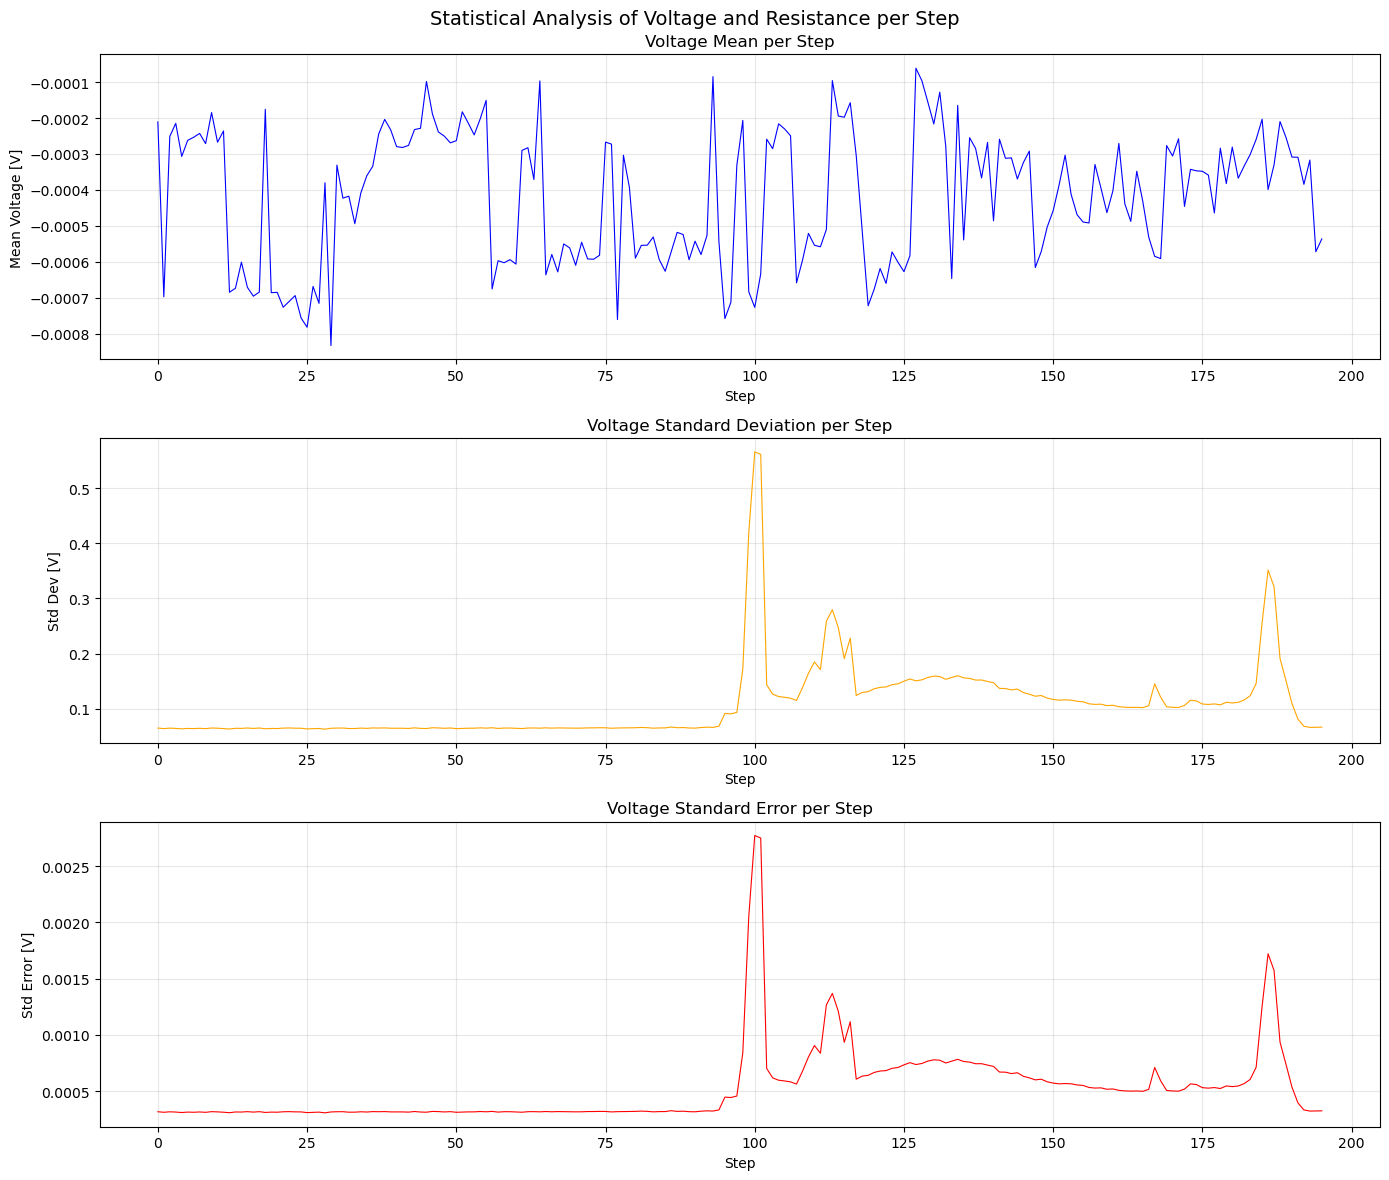

In [37]:
# Import libraries for data handling and plotting
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the previously saved statistics CSV file
stats_df = pd.read_csv('step_statistics.csv')
steps = stats_df['Step'].values

# Create a 3x1 grid of subplots to show mean, std dev, and std error for both Voltage and Resistance
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle('Statistical Analysis of Voltage and Resistance per Step', fontsize=14)

# Voltage Mean
axes[0].plot(steps, stats_df['Voltage_Mean'], color='blue', linewidth=0.8)
axes[0].set_title('Voltage Mean per Step')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Mean Voltage [V]')
axes[0].grid(True, alpha=0.3)

# Voltage Std Dev
axes[1].plot(steps, stats_df['Voltage_Std'], color='orange', linewidth=0.8)
axes[1].set_title('Voltage Standard Deviation per Step')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('Std Dev [V]')
axes[1].grid(True, alpha=0.3)

# Voltage Std Error
axes[2].plot(steps, stats_df['Voltage_StdErr'], color='red', linewidth=0.8)
axes[2].set_title('Voltage Standard Error per Step')
axes[2].set_xlabel('Step')
axes[2].set_ylabel('Std Error [V]')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('step_statistics_voltage_plot.png', dpi=150, bbox_inches='tight')
plt.show()

It can be observed that the mean voltage across each step fluctuates quite randomly, with the highest mean voltage being recorded at step 127. 

Interestingly, the standard deviation and standard error of Machine B1 had identical behavior. The values are quite stationary  up until around the step 95 mark, signifying that there may have been factors that introduced changes to the system starting from that period.

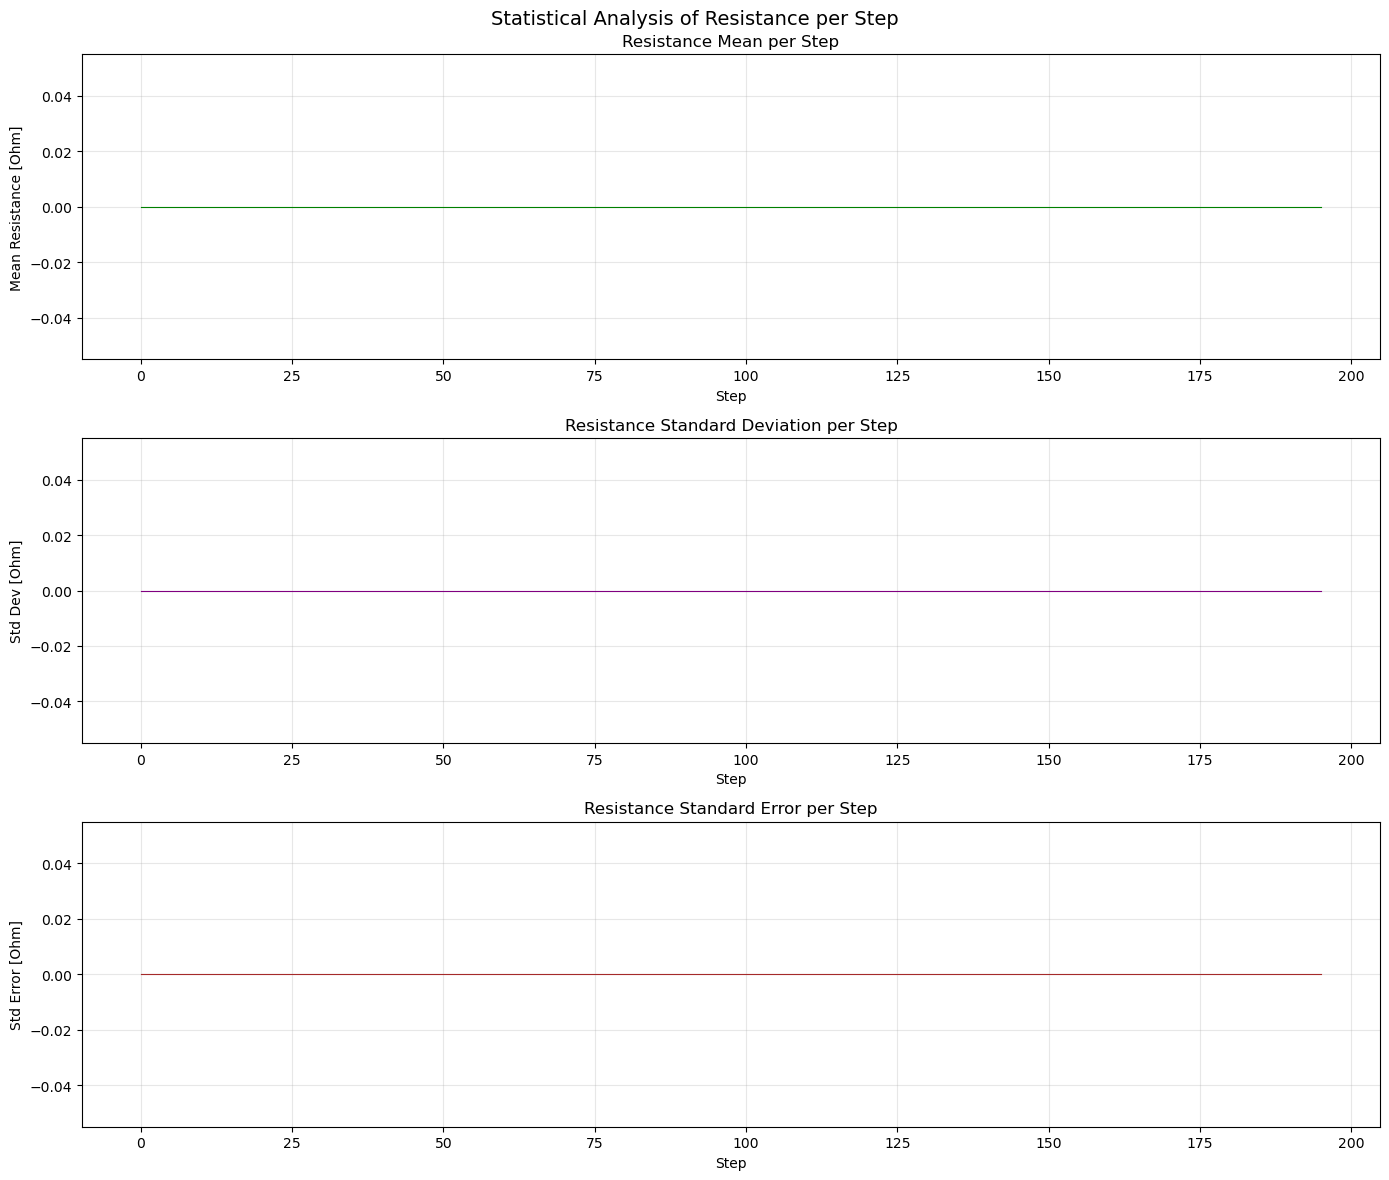

In [42]:
# Resistance Statistics
fig2, axes2 = plt.subplots(3, 1, figsize=(14, 12))
fig2.suptitle('Statistical Analysis of Resistance per Step', fontsize=14)

# Resistance Mean
axes2[0].plot(steps, stats_df['Resistance_Mean'], color='green', linewidth=0.8)
axes2[0].set_title('Resistance Mean per Step')
axes2[0].set_xlabel('Step')
axes2[0].set_ylabel('Mean Resistance [Ohm]')
axes2[0].grid(True, alpha=0.3)

# Resistance Std Dev
axes2[1].plot(steps, stats_df['Resistance_Std'], color='purple', linewidth=0.8)
axes2[1].set_title('Resistance Standard Deviation per Step')
axes2[1].set_xlabel('Step')
axes2[1].set_ylabel('Std Dev [Ohm]')
axes2[1].grid(True, alpha=0.3)

# Resistance Std Error
axes2[2].plot(steps, stats_df['Resistance_StdErr'], color='brown', linewidth=0.8)
axes2[2].set_title('Resistance Standard Error per Step')
axes2[2].set_xlabel('Step')
axes2[2].set_ylabel('Std Error [Ohm]')
axes2[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('step_statistics_resistance_plot.png', dpi=150, bbox_inches='tight')
plt.show()

The recorded resistance across all steps for the machine is 0 all througout. Nothing significamt can be inferred here.

3. Create a program that is able to plot the time-series plots of:
* `G1_Hd1_FTDS_SP1_050418_162003_1_0_0_B1.csv`

The CSV file to be plotted is basically the initial step (step 0).

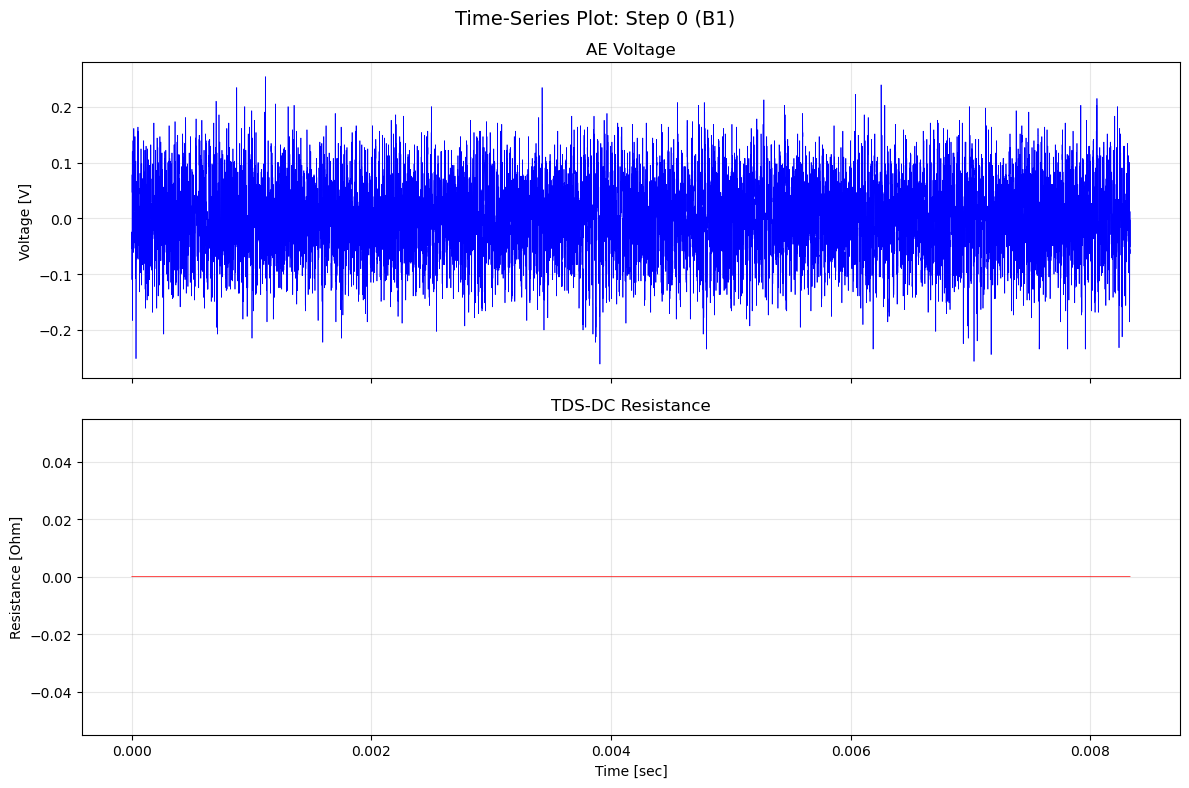

In [39]:
# Import libraries for data handling and plotting
import pandas as pd
import matplotlib.pyplot as plt

# Read the Step 0 CSV file from machine B1, skipping 6 metadata header rows
df = pd.read_csv('dataset/G1_Hd1_FTDS_SP1_050418_162003_1_0_0_B1.csv',
                  skiprows=6, header=0, names=['Time', 'Voltage', 'Resistance'], usecols=[0,1,2])

# Create two vertically stacked subplots sharing the same x-axis (Time)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
fig.suptitle('Time-Series Plot: Step 0 (B1)', fontsize=14)

# Plot Voltage over Time as a continuous time-series signal
ax1.plot(df['Time'], df['Voltage'], color='blue', linewidth=0.5)
ax1.set_ylabel('Voltage [V]')
ax1.set_title('AE Voltage')
ax1.grid(True, alpha=0.3)

# Plot Resistance over Time as a continuous time-series signal
ax2.plot(df['Time'], df['Resistance'], color='red', linewidth=0.5)
ax2.set_ylabel('Resistance [Ohm]')
ax2.set_xlabel('Time [sec]')
ax2.set_title('TDS-DC Resistance')
ax2.grid(True, alpha=0.3)

# Adjust layout and save the plot as a PNG image
plt.tight_layout()
plt.savefig('timeseries_step0.png', dpi=150, bbox_inches='tight')
plt.show()

The current visualizations show that the recorded voltages within the initial step are quite noisy and highly varied. We can use a moving average to look for trends amidst the highly volatile data.

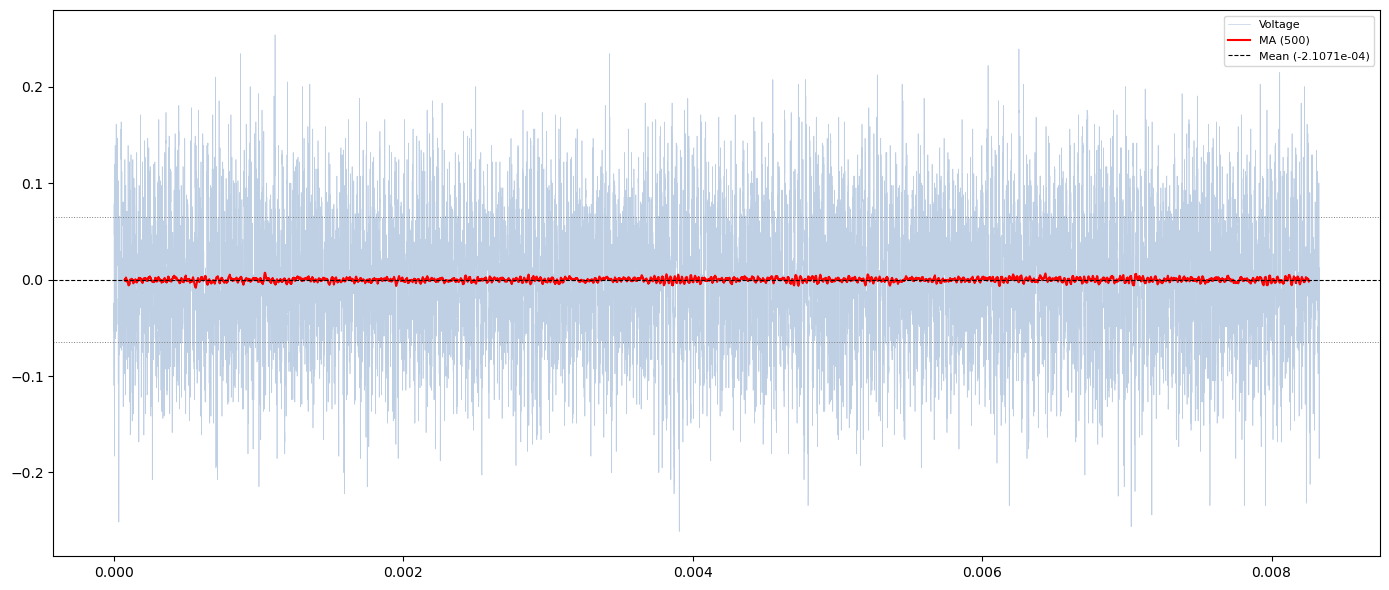

In [54]:
fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.plot(df['Time'], df['Voltage'], color='lightsteelblue', linewidth=0.5, alpha=0.8, label='Voltage')

df['Voltage_MA_500'] = df['Voltage'].rolling(window=750, center=True).mean()

ax1.plot(df['Time'], df['Voltage_MA_500'], color='red', linewidth=1.5, label='MA (500)')

mean_v = df['Voltage'].mean()
std_v = df['Voltage'].std(ddof=1)
ax1.axhline(mean_v, color='black', linestyle='--', linewidth=0.8, label=f'Mean ({mean_v:.4e})')
ax1.axhline(mean_v + std_v, color='gray', linestyle=':', linewidth=0.7)
ax1.axhline(mean_v - std_v, color='gray', linestyle=':', linewidth=0.7)
ax1.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig('timeseries_movingaverage_step0.png', dpi=150, bbox_inches='tight')
plt.show()

In getting the moving average per 750 samples (window = 750), it can be observed that the signals are quite stationary, and there are no notable anomalies within the machine's records. It suggests that the machine runs as usual, despite the volatility of the data.

4. Also, plot the histogram of voltage and resistance of `G1_Hd1_FTDS_SP1_050418_162003_1_0_0_B1.csv` for its first 1500 samples. Then try 8000 samples, then 25000 samples, and lastly, all samples.

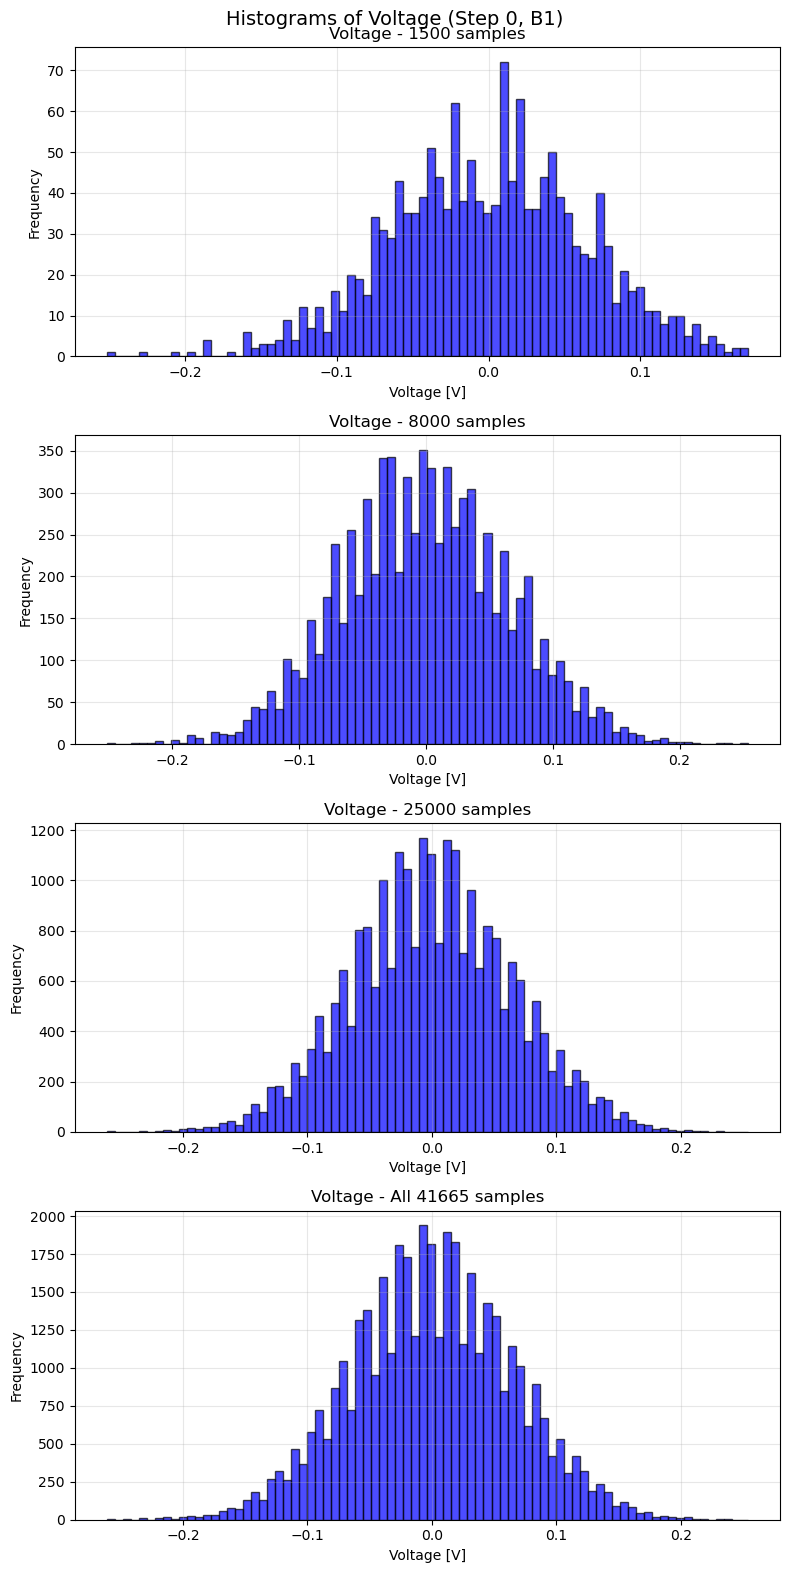

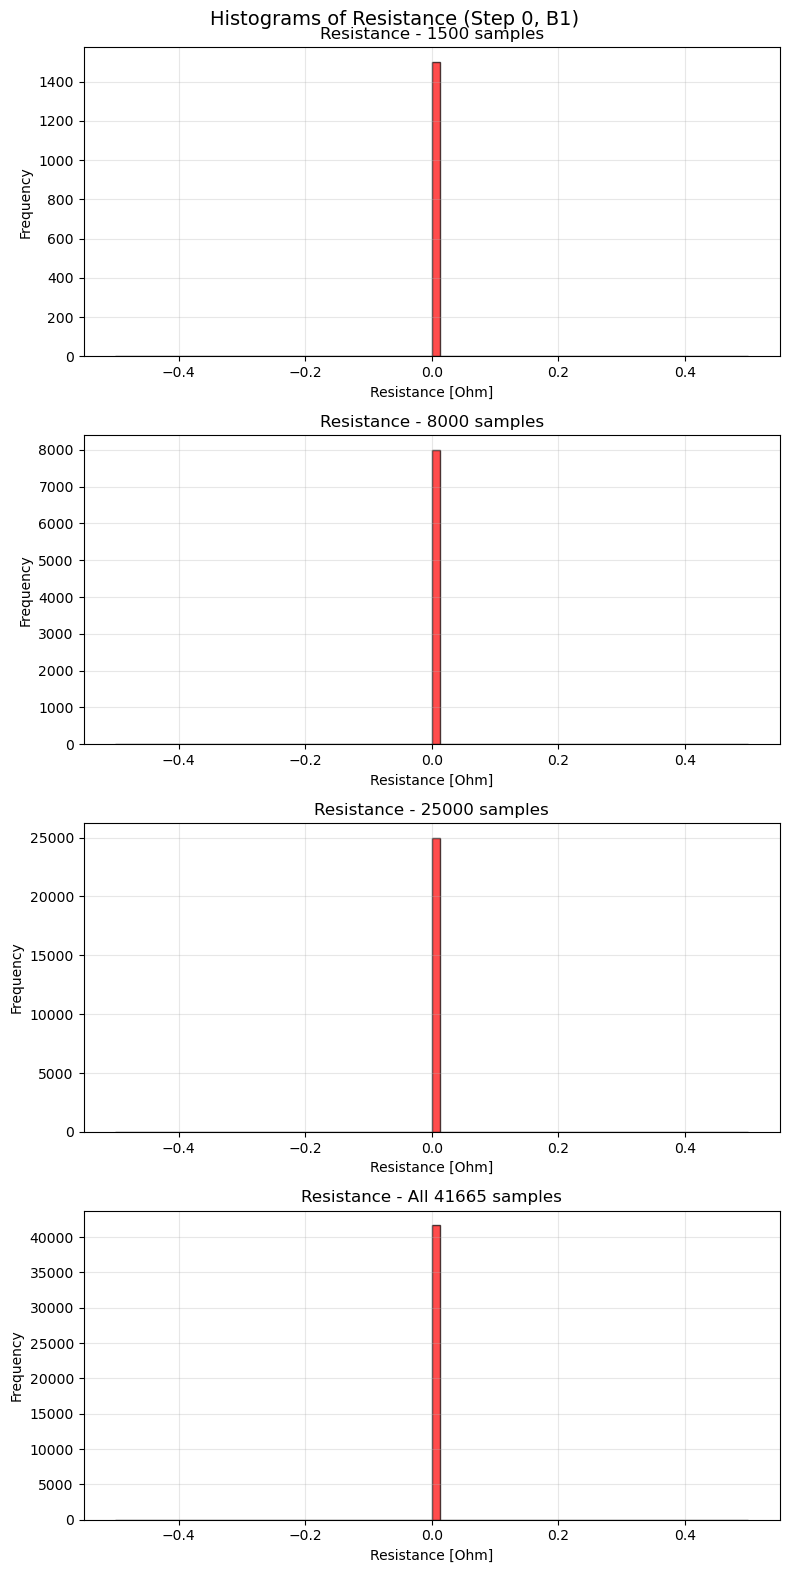

In [41]:
# Import libraries for data handling and plotting
import pandas as pd
import matplotlib.pyplot as plt

# Read the Step 0 CSV file from machine B1, skipping 6 metadata header rows
df = pd.read_csv('dataset/G1_Hd1_FTDS_SP1_050418_162003_1_0_0_B1.csv',
                  skiprows=6, header=0, names=['Time', 'Voltage', 'Resistance'], usecols=[0, 1, 2])

# Define the sample sizes to compare: 1500, 8000, 25000, and all samples
sample_sizes = [1500, 8000, 25000, len(df)]

# Figure 1: Voltage histograms
fig1, axes1 = plt.subplots(4, 1, figsize=(8, 16))
fig1.suptitle('Histograms of Voltage (Step 0, B1)', fontsize=14)

for i, n in enumerate(sample_sizes):
    label = f'{n} samples' if n != len(df) else f'All {n} samples'

    axes1[i].hist(df['Voltage'].iloc[:n], bins=80, color='blue', edgecolor='black', alpha=0.7)
    axes1[i].set_title(f'Voltage - {label}')
    axes1[i].set_xlabel('Voltage [V]')
    axes1[i].set_ylabel('Frequency')
    axes1[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('histograms_voltage_step0.png', dpi=150, bbox_inches='tight')
plt.show()

# Figure 2: Resistance histograms
fig2, axes2 = plt.subplots(4, 1, figsize=(8, 16))
fig2.suptitle('Histograms of Resistance (Step 0, B1)', fontsize=14)

for i, n in enumerate(sample_sizes):
    label = f'{n} samples' if n != len(df) else f'All {n} samples'

    axes2[i].hist(df['Resistance'].iloc[:n], bins=80, color='red', edgecolor='black', alpha=0.7)
    axes2[i].set_title(f'Resistance - {label}')
    axes2[i].set_xlabel('Resistance [Ohm]')
    axes2[i].set_ylabel('Frequency')
    axes2[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('histograms_resistance_step0.png', dpi=150, bbox_inches='tight')
plt.show()

From the histograms, it can be observed that the recorded samples are quite consistent with a normal distribution curve. The difference is that in the first 1500 samples, the distribution is left-skewed, suggesting that the samples are skewed towards the slightly higher voltages. However, as more samples get included in the histograms, the skewness slowly disappears.

## 6. Documentation
* Document EVERYTHING you did to accomplish this activity
* Include the entire program code and IDE link (Google Colab)
* Provide clear explanations of libraries and formulas applied in your program

## 7. Summary and Conclusions

In summary, it can be concluded that the recorded voltage samples from Machine B1 show no major anomalies, as shown by the moving average. However, it should be noted that a sudden spike in standard deviation and standard error around step 95 onwards show that there may have been variables that must have caused it, and should be a case for inquiry.

## 8. Artificial Intelligence (AI) Use Disclosure Statement

I hereby declare that artificial intelligence (AI) tools were used, if applicable, in the preparation of this academic
work. The following indicates the nature and extent of AI assistance:

**Tools Used**: Github Copilot, Opencode, Claude
<br>*Examples: ChatGPT, Microsoft Copilot, Grammarly, QuillBot, etc*<br>

**Purpose of Use**: Code Debugging, Code assistance, Code explanation
<br>*Examples: grammar correction, idea generation, formatting, summarization, code assistance, explanation of
concepts, etc*<br>
**Extent of Use**: AI was used to help understand how the tasks needed to be done can be translated into readable, functional code. The methods in data preprocessing and data interpretation were done with my own effort and analysis.
<br>*Explain how AI was used and confirm that it did not replace original thinking, analysis, authorship, or
completion of the required work*<br>

***
By submitting this activity, I affirm that my use of AI complies with T.I.P.’s AI usage policy and does not exceed the
permitted limits for similarity, automated content generation, or academic assistance.

I understand that any false, incomplete, or misleading disclosure may be subject to investigation in accordance
with due process and may result in sanctions for violation of existing T.I.P. policies.